# Assignment 2. Option 2

## Dataset Exploration

In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
!bash ./src/download_voxconverse.sh

Annotations already present, skipping clone.
Audio already present, skipping download.


## Pyannote-Based System

## Custom Implementation (PyTorch / Torchaudio / PyTorch-Lightning)

In [21]:
from pathlib import Path
from src.dataset import VoxConverseDataset, AudioSampler, make_collate_fn
from src.models import MelSpectrogramExtractor, VoiceActivityDetector
from src.train import train_vad, plot_history
from torch.utils.data import DataLoader
import soundfile as sf
import torch
import matplotlib.pyplot as plt

DATA_DIR = Path("data")
AUDIO_DIR = DATA_DIR / "audio"
ANNOTATIONS_DIR = DATA_DIR / "annotations"
IMG_DIR = Path("img")
MODELS_DIR = Path("models")
DIR_DEV = "dev"
DIR_TEST = "test"
SAMPLE_RATE = 16_000
HOP = 10
VAD_MODEL = MODELS_DIR / "vad.pt"

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [22]:
dataset_dev = VoxConverseDataset(
  annotations_dir=ANNOTATIONS_DIR / DIR_DEV,
  audio_dir=AUDIO_DIR / DIR_DEV,
  sample_rate=SAMPLE_RATE,
)

dataset_test = VoxConverseDataset(
  annotations_dir=ANNOTATIONS_DIR / DIR_TEST,
  audio_dir=AUDIO_DIR / DIR_TEST,
  sample_rate=SAMPLE_RATE,
)

dev_lengths  = [sf.info(p).frames for p in dataset_dev.audio_files]
test_lengths = [sf.info(p).frames for p in dataset_test.audio_files]

dataloader_dev = DataLoader(
  dataset_dev,
  batch_sampler=AudioSampler(dev_lengths, batch_size=8, shuffle=True),
  collate_fn=make_collate_fn(HOP, SAMPLE_RATE),
)

dataloader_test = DataLoader(
  dataset_test,
  batch_sampler=AudioSampler(dev_lengths, batch_size=8, shuffle=False),
  collate_fn=make_collate_fn(HOP, SAMPLE_RATE),
)

### A Voice Activity Detection (VAD) model using a supervised neural network approach

<div align="center"><img src="img/vad.png" height="800"></div>

torch.Size([8, 76532])
speech fraction: 0.8944362998008728


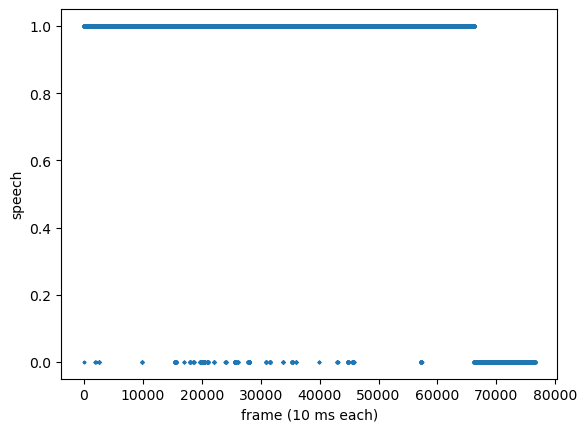

In [23]:
(waveform, labels, mask) = next(iter(dataloader_dev))

print(labels.shape)
print("speech fraction:", labels.float().mean().item())
y = labels[0].numpy()
x = range(len(y))

plt.scatter(x, y, s=2)
plt.xlabel("frame (10 ms each)")
plt.ylabel("speech")
plt.show()

In [24]:
VAD_RETRAIN=False

if VAD_MODEL.exists() and not VAD_RETRAIN:
  print(f"VAD already exists at {VAD_MODEL}")
else:
  epochs = 7
  lr = 1e-3

  print(f"Device: {device}")

  vad = VoiceActivityDetector(
    device=device,
    spectrogram_layer=MelSpectrogramExtractor(
      sample_rate=SAMPLE_RATE,
      hop_ms=HOP,
    )
  )

  history = train_vad(vad, device, lr, epochs, dataloader_dev, dataloader_test)
  fig = plot_history(history)
  fig.savefig(IMG_DIR / "vad_metrics.png", dpi=150, bbox_inches="tight")
  fig.show()

  torch.save(vad.state_dict(), MODELS_DIR / "vad.pt")

VAD already exists at models/vad.pt
